<a href="https://colab.research.google.com/github/Nikhilvijai/internship/blob/main/football_leagues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!unzip /content/archive.zip -d /content/football_league


Archive:  /content/archive.zip
  inflating: /content/football_league/top-5-football-leagues/bundesliga/augsburg.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/bayern.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/bremen.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/dortmund.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/dusseldorf.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/frankfurt.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/freiburg.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/furth.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/hamburg.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/hannover.png  
  inflating: /content/football_league/top-5-football-leagues/bundesliga/hertha-bsc-berlin.png  
  inflat

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

league_images = []

base_path = "/content/football_league/top-5-football-leagues"

for league in os.listdir(base_path):
    league_path = os.path.join(base_path, league)

    if os.path.isdir(league_path):
        files = [f for f in os.listdir(league_path)
                 if f.lower().endswith((".jpg",".jpeg",".png"))]

        if files:
            league_images.append(os.path.join(league_path, files[0]))

print("Selected:", len(league_images))

Selected: 5


In [9]:
league_images

['/content/football_league/top-5-football-leagues/la-liga/granada.png',
 '/content/football_league/top-5-football-leagues/french-ligue1/estac-troyes.png',
 '/content/football_league/top-5-football-leagues/serie-a/bologna.png',
 '/content/football_league/top-5-football-leagues/bundesliga/wolfsburg.png',
 '/content/football_league/top-5-football-leagues/premier-league/newcastle-united.png']

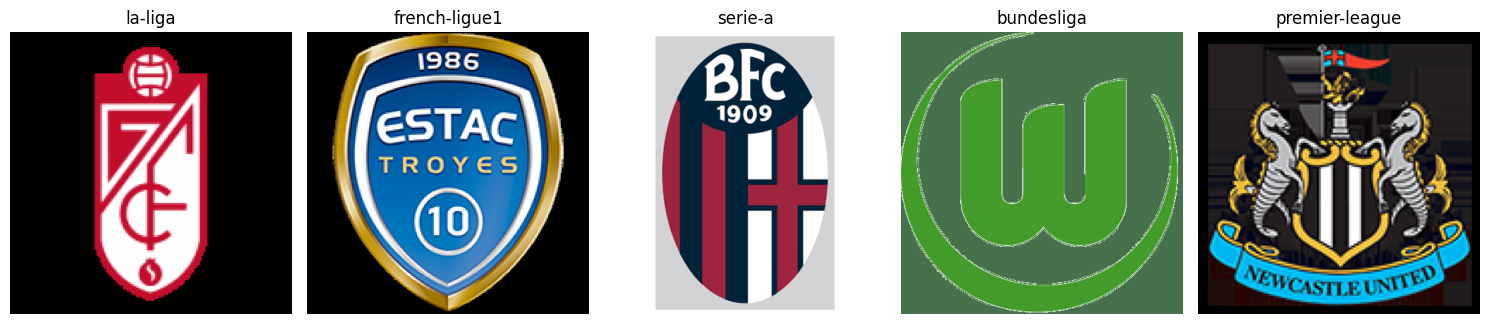

In [10]:
plt.figure(figsize=(15,5))

for i, path in enumerate(league_images):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
import cv2
import pandas as pd
import os

all_image_data = []

for subdir in os.listdir(base_path):
  dir_path = os.path.join(base_path, subdir)
  for f in os.listdir(dir_path):
    img_path = os.path.join(dir_path, f)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}")
        continue

    height, width, channels = img.shape

    image_info = {
        "Filename": os.path.basename(img_path),
        "Width (px)": width,
        "Height (px)": height,
        "Channels": subdir
    }
    all_image_data.append(image_info)

df = pd.DataFrame(all_image_data)

print("Image Data DataFrame created successfully:")
print(df.head())

Image Data DataFrame created successfully:
       Filename  Width (px)  Height (px) Channels
0   granada.png         150          150  la-liga
1   sevilla.png         150          150  la-liga
2   levante.png         150          150  la-liga
3     cadiz.png         150          150  la-liga
4  espanyol.png         150          150  la-liga


In [19]:
import cv2
import pandas as pd
import os

all_image_data = []

for subdir in os.listdir(base_path):
  dir_path = os.path.join(base_path, subdir)
  for f in os.listdir(dir_path):
    img_path = os.path.join(dir_path, f)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}")
        continue

    height, width, channels = img.shape

    image_info = {
        "Filename": os.path.basename(img_path),
        "Width (px)": width,
        "Height (px)": height,
        "Channels": subdir
    }
    all_image_data.append(image_info)

df_resized = pd.DataFrame(all_image_data)

print(df_resized.head())

       Filename  Width (px)  Height (px) Channels
0   granada.png         224          224  la-liga
1   sevilla.png         224          224  la-liga
2   levante.png         224          224  la-liga
3     cadiz.png         224          224  la-liga
4  espanyol.png         224          224  la-liga


In [20]:
df_resized

,Filename,Width (px),Height (px),Channels
0,granada.png,224,224,la-liga
1,sevilla.png,224,224,la-liga
2,levante.png,224,224,la-liga
3,cadiz.png,224,224,la-liga
4,espanyol.png,224,224,la-liga
...,...,...,...,...
95,brentford.png,224,224,premier-league
96,watford.png,224,224,premier-league
97,chelsea.png,224,224,premier-league
98,manchester-united.png,224,224,premier-league


In [18]:
import cv2

target_size = (224, 224)

for subdir in os.listdir(base_path):
  dir_path = os.path.join(base_path, subdir)
  for f in os.listdir(dir_path):
    img_path = os.path.join(dir_path, f)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}")
        continue
    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    cv2.imwrite(img_path, resized_img)

print(f"\nFinished resizing. Total 100 images resized to '{target_size}'")


Finished resizing. Total 100 images resized to '(224, 224)'


In [21]:
league_images

['/content/football_league/top-5-football-leagues/la-liga/granada.png',
 '/content/football_league/top-5-football-leagues/french-ligue1/estac-troyes.png',
 '/content/football_league/top-5-football-leagues/serie-a/bologna.png',
 '/content/football_league/top-5-football-leagues/bundesliga/wolfsburg.png',
 '/content/football_league/top-5-football-leagues/premier-league/newcastle-united.png']

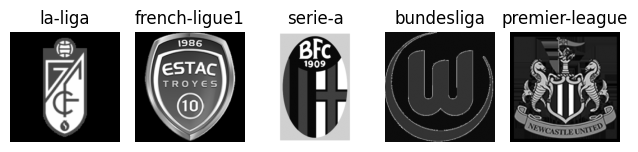

In [23]:
from cv2 import cvtColor, COLOR_BGR2GRAY

for i, path in enumerate(league_images):
    img = cv2.imread(path)
    img = cvtColor(img, COLOR_BGR2GRAY)

    plt.subplot(1,5,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis("off")

plt.tight_layout()
plt.show()

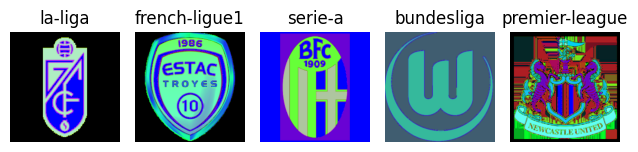

In [24]:
from cv2 import cvtColor, COLOR_BGR2HSV

for i, path in enumerate(league_images):
    img = cv2.imread(path)
    img = cvtColor(img, COLOR_BGR2HSV)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import cv2
import numpy as np
import pandas as pd

# Create empty column
df_resized["vector_rep"] = None

for idx, filename in enumerate(df_resized["Filename"]):

    image_found = False

    # Search for the image in all subdirectories
    for subdir in os.listdir(base_path):

        dir_path = os.path.join(base_path, subdir)

        # Skip files in the base directory
        if not os.path.isdir(dir_path):
            continue

        img_path = os.path.join(dir_path, filename)

        if os.path.exists(img_path):

            img = cv2.imread(img_path)

            if img is None:
                print(f"Warning: Could not load image {img_path}")
                break

            # Normalize pixel values
            image_array = img.astype(np.float32) / 255.0

            # Convert image to 1D vector
            vector_rep = image_array.flatten()

            # Store vector in dataframe
            df_resized.at[idx, "vector_rep"] = vector_rep

            image_found = True
            break

    if not image_found:
        print(f"Image not found: {filename}")

print("Done!")

Done!


In [26]:
df_resized

,Filename,Width (px),Height (px),Channels,vector_rep
0,granada.png,224,224,la-liga,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,sevilla.png,224,224,la-liga,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,levante.png,224,224,la-liga,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,cadiz.png,224,224,la-liga,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,espanyol.png,224,224,la-liga,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...
95,brentford.png,224,224,premier-league,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
96,watford.png,224,224,premier-league,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
97,chelsea.png,224,224,premier-league,"[0.06666667, 0.6313726, 0.85882354, 0.06666667..."
98,manchester-united.png,224,224,premier-league,"[0.0, 0.0, 0.0, 0.043137256, 0.047058824, 0.04..."


In [30]:
import os
import cv2
import numpy as np
import pandas as pd

# Path containing image subfolders
base_path = "/content/football_league/top-5-football-leagues"

# Create the new column
df_resized["vector_rep"] = None

for idx, filename in enumerate(df_resized["Filename"]):

    image_found = False

    for subdir in os.listdir(base_path):

        dir_path = os.path.join(base_path, subdir)

        # Skip if not a directory
        if not os.path.isdir(dir_path):
            continue

        img_path = os.path.join(dir_path, filename)

        if os.path.exists(img_path):

            # Read image
            img = cv2.imread(img_path)

            if img is None:
                print(f"Warning: Could not load image: {img_path}")
                break

            # Resize image (optional but recommended)
            img = cv2.resize(img, (128, 128))

            # Gaussian Blur
            img = cv2.GaussianBlur(img, (5, 5), 0)

            # Median Blur
            img = cv2.medianBlur(img, 5)

            # Normalize pixel values
            img = img.astype(np.float32) / 255.0

            # Flatten image into 1D vector
            vector_rep = img.flatten()

            # Store vector in dataframe
            df_resized.at[idx, "vector_rep"] = vector_rep

            image_found = True
            break

    if not image_found:
        print(f"Image not found: {filename}")

print("Processing completed!")

# Remove rows where image wasn't found
df_resized = df_resized.dropna(subset=["vector_rep"])

# Convert vectors to feature matrix
X = np.vstack(df_resized["vector_rep"].values)

print("Feature matrix shape:", X.shape)
print(df_resized.head())

Processing completed!
Feature matrix shape: (100, 49152)
       Filename  Width (px)  Height (px) Channels  \
0   granada.png         224          224  la-liga   
1   sevilla.png         224          224  la-liga   
2   levante.png         224          224  la-liga   
3     cadiz.png         224          224  la-liga   
4  espanyol.png         224          224  la-liga   

                                          vector_rep  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  


In [35]:
df_resized["vector_rep"][1]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

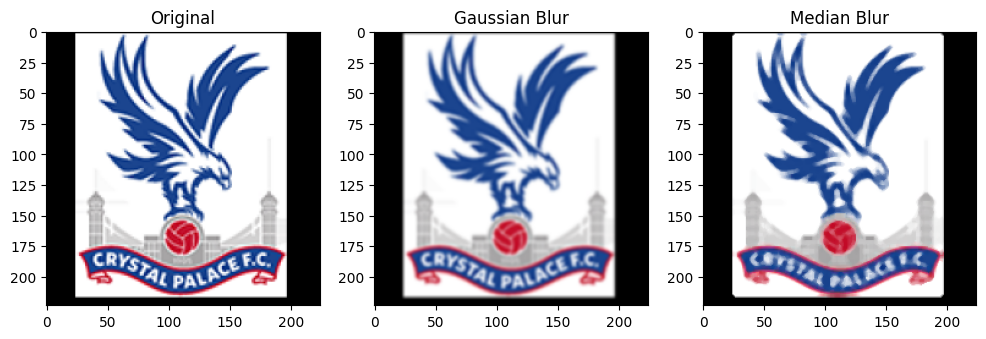

In [36]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gaussian = cv2.GaussianBlur(img_rgb, (5, 5), 0)
median = cv2.medianBlur(img_rgb, 5)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(gaussian)
plt.title("Gaussian Blur")

plt.subplot(1,3,3)
plt.imshow(median)
plt.title("Median Blur")

plt.show()

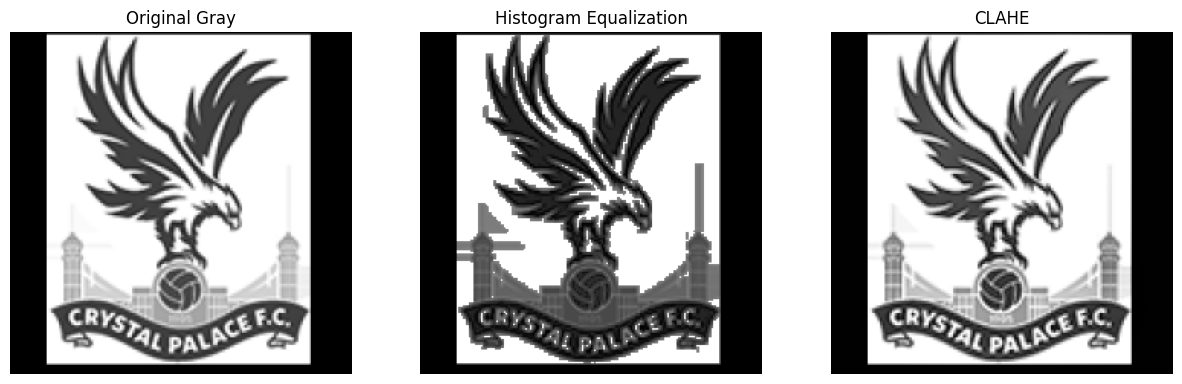

In [37]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(img_path)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Histogram Equalization
hist_eq = cv2.equalizeHist(gray)

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
clahe_img = clahe.apply(gray)

# Display
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Gray")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hist_eq, cmap='gray')
plt.title("Histogram Equalization")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

plt.show()

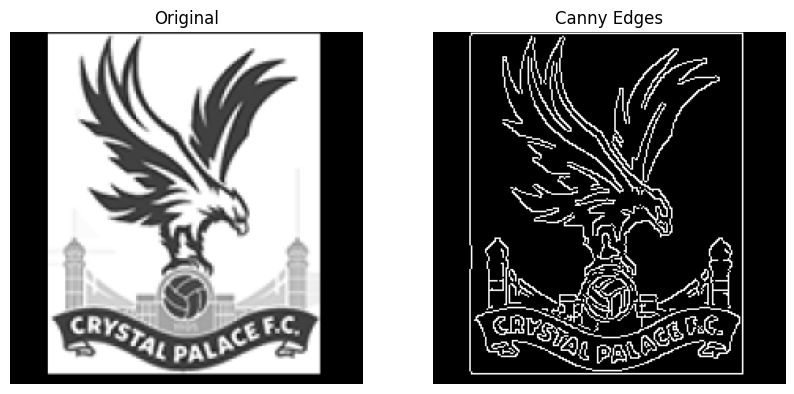

In [38]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(img_path)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')

plt.show()

In [39]:
img_path

'/content/football_league/top-5-football-leagues/premier-league/crystal-palace.png'

In [41]:
from PIL import Image, ImageEnhance, ImageOps
import os

count = 0
for pat in league_images:
    image_path = pat  # Replace with your image file path
    image = Image.open(image_path)


    augmented_dir = f"augmented_images{count}"
    #Creates the directory augmented_images
    os.makedirs(augmented_dir, exist_ok=True)
    #Ensures no error is raised if the directory already exists.

    # Augmentation functions
    def augment_image(image, output_dir):
        # 1. Horizontal Flip
        # Flips the image horizontally (mirroring).
        flipped = ImageOps.mirror(image)
        #Saves the flipped image as flipped.jpeg in the output_dir
        flipped.save(os.path.join(output_dir, "flipped.jpeg"))

        # 2. Rotate
        rotated = image.rotate(30)
        #Rotates the image by 30 degrees (counterclockwise by default)
        rotated.save(os.path.join(output_dir, "rotated.jpeg"))

        # 3. Brightness Adjustment
        enhancer = ImageEnhance.Brightness(image)
        #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
        brighter = enhancer.enhance(1.5)
        brighter.save(os.path.join(output_dir, "brighter.jpeg"))

        # 4. Contrast Adjustment
        contrast = ImageEnhance.Contrast(image).enhance(2.0)
        #Doubles the image's contrast (2.0 = twice the original contrast).

        contrast.save(os.path.join(output_dir, "contrast.jpeg"))

        # 5. Grayscale
        grayscale = ImageOps.grayscale(image)
        grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

    # Apply augmentations
    augment_image(image, augmented_dir)
    count+=1
    print("Augmented images saved in:", augmented_dir)
    print("Generated files:", os.listdir(augmented_dir))


Augmented images saved in: augmented_images0
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']
Augmented images saved in: augmented_images1
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']
Augmented images saved in: augmented_images2
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']
Augmented images saved in: augmented_images3
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']
Augmented images saved in: augmented_images4
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


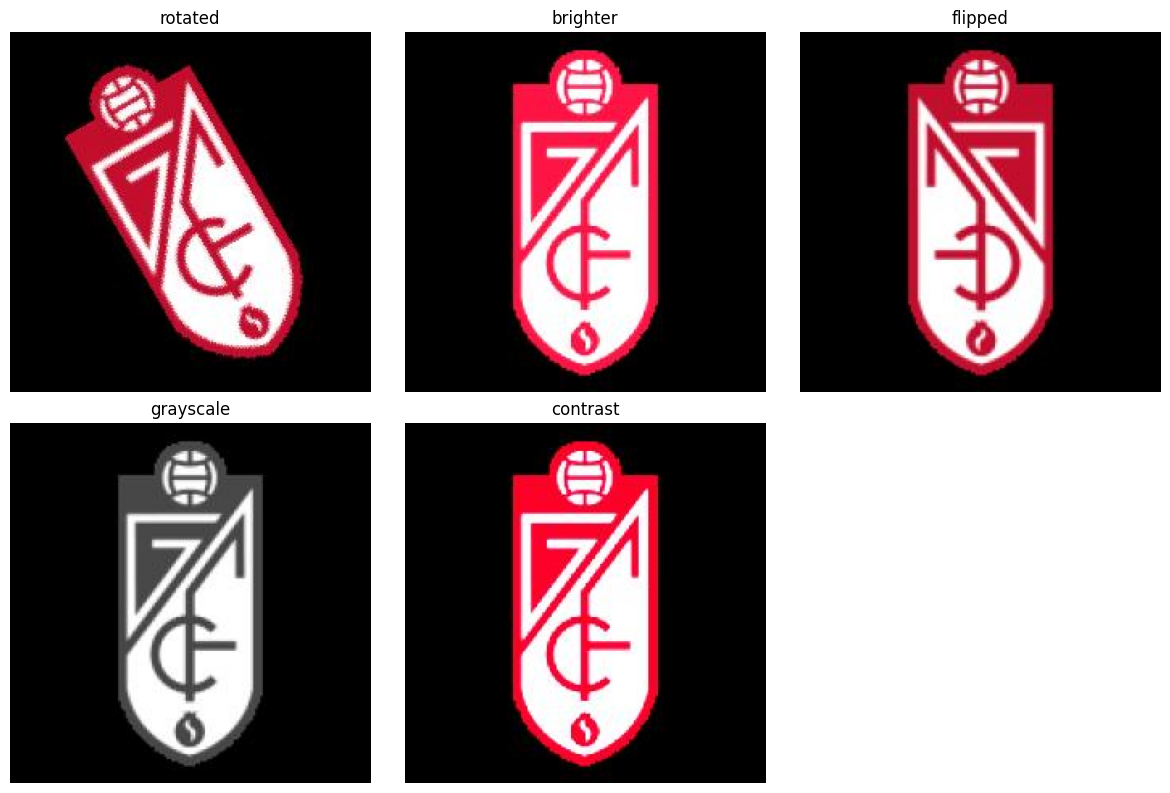

In [42]:
import matplotlib.pyplot as plt

augmented_dir = "augmented_images0"

augmented_images = os.listdir(augmented_dir)

plt.figure(figsize=(12,8))

for i,img_file in enumerate(augmented_images):
    img_path = os.path.join(augmented_dir, img_file)
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="grey" if img.mode == "L" else None)
    plt.title(img_file.split('.')[0])
    plt.axis('off')

plt.tight_layout()
plt.show()